<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Import Needed Libraries</h2>
</div>

In [1]:
import emoji
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datasets import Dataset
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification , TrainingArguments , Trainer , EarlyStoppingCallback

c:\Users\Ahmed\anaconda3\envs\mental\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Load Data</h2>
</div>

#### Load the Data and Concate into one Data

In [2]:
reddit_df = pd.read_csv('Depression Reddit Dataset (Cleaned)/depression_dataset_reddit_cleaned.csv')
twitter_train_df = pd.read_csv('DepressionTweets/train2Data.csv')
twitter_test_df = pd.read_csv('DepressionTweets/test2Data.csv')

#### Information about the datasets

In [3]:
print("Data1 (Reddit Dataset) Info:\n")
print(reddit_df.info())
print("Is there any missing data in Data1? ", reddit_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data1? ", reddit_df.duplicated().sum(),"\n")
print("Is there any imbalance in the target variable in Data1? ", reddit_df['is_depression'].value_counts(),"\n")

Data1 (Reddit Dataset) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7731 entries, 0 to 7730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_text     7731 non-null   object
 1   is_depression  7731 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 120.9+ KB
None
Is there any missing data in Data1?  False 

Is there any duplicate data in Data1?  81 

Is there any imbalance in the target variable in Data1?  is_depression
0    3900
1    3831
Name: count, dtype: int64 



In [4]:
print("Data2 (DepressionTweets Train) Info:\n")
print(twitter_train_df.info())
print("Is there any missing data in Data2? ", twitter_train_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data2? ", twitter_train_df.duplicated().sum(),"\n")
twitter_train_df.columns = twitter_train_df.columns.str.strip() # Remove leading/trailing whitespace from column names
print("Is there any imbalance in the target variable in Data2? ", twitter_train_df['Label'].value_counts(),"\n")

Data2 (DepressionTweets Train) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31000 entries, 0 to 30999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweets  31000 non-null  object
 1    Label  31000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 484.5+ KB
None
Is there any missing data in Data2?  False 

Is there any duplicate data in Data2?  932 

Is there any imbalance in the target variable in Data2?  Label
1    16000
0    15000
Name: count, dtype: int64 



In [5]:
print("Data3 (DepressionTweets Test) Info:\n")
print(twitter_test_df.info())
print("Is there any missing data in Data3? ", twitter_test_df.isnull().sum().any(),"\n")
print("Is there any duplicate data in Data3? ", twitter_test_df.duplicated().sum(),"\n")
twitter_test_df.columns = twitter_test_df.columns.str.strip() # Remove leading/trailing whitespace from column names
print("Is there any imbalance in the target variable in Data3? ", twitter_test_df['Label'].value_counts(),"\n")

Data3 (DepressionTweets Test) Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31000 entries, 0 to 30999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweets  31000 non-null  object
 1    Label  31000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 484.5+ KB
None
Is there any missing data in Data3?  False 

Is there any duplicate data in Data3?  1956 

Is there any imbalance in the target variable in Data3?  Label
1    16000
0    15000
Name: count, dtype: int64 



#### Concatenate the datasets

In [6]:
reddit_df.rename(columns={"clean_text": "text", "is_depression": "label"}, inplace=True)
twitter_train_df.rename(columns={"Tweets": "text", "Label": "label"}, inplace=True)
twitter_test_df.rename(columns={"Tweets": "text", "Label": "label"}, inplace=True)

In [7]:
df = pd.concat([
    reddit_df[["text", "label"]], 
    twitter_train_df[["text", 'label']], 
    twitter_test_df[["text", 'label']], 
], ignore_index=True)

In [8]:
# Show the combined dataset info
print("Combined Dataset Info:\n")
print(df.info())
print("Is there any duplicate data in Combined Data?")
print(df.duplicated().sum())

Combined Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69731 entries, 0 to 69730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    69731 non-null  object
 1   label   69731 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
Is there any duplicate data in Combined Data?


2969


#### Handle Duplicates Rows (Remove It)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
# Show the combined dataset info after remove duplicates
print("Combined Dataset Info:\n")
print(df.info())
print("Is there any duplicate data in Combined Data?")
print(df.duplicated().sum())

Combined Dataset Info:

<class 'pandas.core.frame.DataFrame'>
Index: 66762 entries, 0 to 69730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    66762 non-null  object
 1   label   66762 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB
None
Is there any duplicate data in Combined Data?
0


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Basic Dataset Overview (EDA)</h2>
</div>

#### Class Distribution (Check if dataset is balanced)

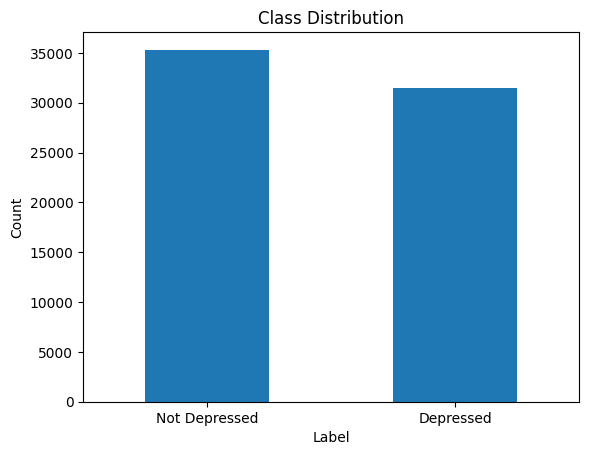

In [11]:
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.xticks([0, 1], ["Not Depressed", "Depressed"],rotation=0)
plt.ylabel("Count")
plt.show()

#### Text Length Analysis

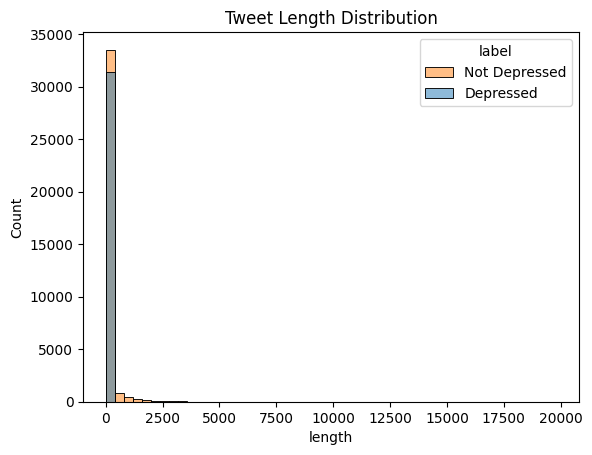

In [12]:
df['length'] = df['text'].apply(len)
df.groupby('label')['length'].describe()
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Tweet Length Distribution")
plt.legend(title='label', labels=['Not Depressed', 'Depressed'])
plt.show()

#### Word Count Analysis

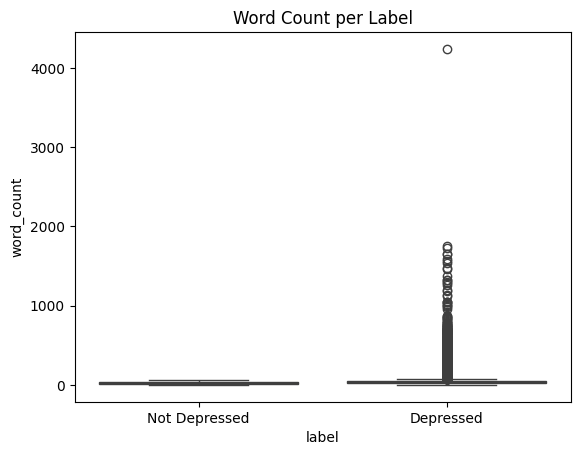

In [13]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df)
plt.title("Word Count per Label")
plt.xticks([0, 1], ["Not Depressed", "Depressed"])
plt.show()

#### Most Frequent Words

In [14]:
stop_words = set(stopwords.words('english'))

def clean_for_eda(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    words = [word for word in text.split() if word not in stop_words]
    
    return " ".join(words)

stress_text = " ".join(df[df.label == 1]['text'].apply(clean_for_eda))
no_stress_text = " ".join(df[df.label == 0]['text'].apply(clean_for_eda))

stress_words = Counter(stress_text.split()).most_common(20)
no_stress_words = Counter(no_stress_text.split()).most_common(20)

print("Stress words:", stress_words)
print("No stress words:", no_stress_words)

Stress words: [('depression', 14520), ('want', 12527), ('feel', 10994), ('like', 9906), ('cry', 9144), ('depressed', 8573), ('life', 8492), ('hate', 6422), ('get', 5984), ('stressed', 5798), ('anxiety', 5611), ('today', 5603), ('know', 5514), ('people', 5274), ('time', 4791), ('really', 4681), ('absolutely', 4493), ('damn', 4398), ('miserable', 4301), ('severe', 4297)]
No stress words: [('like', 4734), ('one', 2634), ('get', 2295), ('time', 2067), ('good', 1980), ('love', 1973), ('people', 1859), ('know', 1776), ('amp', 1744), ('favorite', 1683), ('best', 1627), ('would', 1580), ('voting', 1502), ('amas', 1469), ('think', 1431), ('really', 1397), ('day', 1379), ('see', 1378), ('dont', 1336), ('want', 1303)]


#### WordCloud Visualization

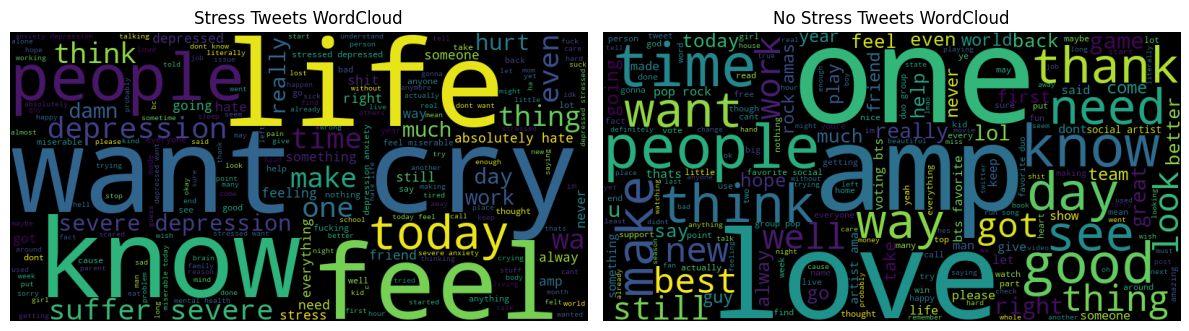

In [15]:
plt.figure(figsize=(12, 6))  

plt.subplot(1, 2, 1)
wc_stress = WordCloud(width=800, height=400).generate(stress_text)
plt.imshow(wc_stress)
plt.axis("off")
plt.title("Stress Tweets WordCloud")

plt.subplot(1, 2, 2)
wc_not_stress = WordCloud(width=800, height=400).generate(no_stress_text)
plt.imshow(wc_not_stress)
plt.axis("off")
plt.title("No Stress Tweets WordCloud")

plt.tight_layout()
plt.show()  

#### Special Patterns (Count punctuation intensity)

In [16]:
df['exclamation'] = df['text'].apply(lambda x: x.count('!'))
df['question'] = df['text'].apply(lambda x: x.count('?'))

df.groupby('label')[['exclamation','question']].mean()

,exclamation,question
label,,
0,0.0,0.0
1,0.0,0.0


In [17]:
# Is Emojis a factor?
df['emoji_count'] = df['text'].apply(lambda x: sum(1 for c in x if c in emoji.EMOJI_DATA))
df.groupby('label')['emoji_count'].mean()

label
0    0.0
1    0.0
Name: emoji_count, dtype: float64

In [18]:
# URL / Mention / Hashtag Analysis is also a factor?
df['has_url'] = df['text'].str.contains("http").astype(int)
df['has_mention'] = df['text'].str.contains("@").astype(int)
df['has_hashtag'] = df['text'].str.contains("#").astype(int)

df.groupby('label')[['has_url','has_mention','has_hashtag']].mean()

,has_url,has_mention,has_hashtag
label,,,
0,0.004008,0.0,0.0
1,0.005634,0.0,0.0


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Cleaning the Text</h2>
</div>

In [19]:
# Text Cleaning for Modeling
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"<.*?>", "", text)     # remove HTML
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [20]:
# Train-test split for modeling (70% train, 30% test and validation)
x_train, x_temp, y_train, y_temp = train_test_split(df['clean_text'],df['label'], test_size=0.3, random_state=42, stratify=df['label'])
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#### Show the shapes of the splits

In [21]:
print(f"Number of Train Texts {x_train.shape}")
print(f"Number of Train Labels {y_train.shape}")
print(f"Number of Validation Texts {x_val.shape}")
print(f"Number of Validation Labels {y_val.shape}")
print(f"Number of Test Texts {x_test.shape}")  
print(f"Number of Test Labels {y_test.shape}")  

Number of Train Texts (46733,)
Number of Train Labels (46733,)
Number of Validation Texts (10014,)
Number of Validation Labels (10014,)
Number of Test Texts (10015,)
Number of Test Labels (10015,)


<div style="background-color:black;
            color:white;
            transform:skew(-20deg);
            padding:30px;
            font-family:Verdana;
            letter-spacing:1px;
            margin:auto;
            width:fit-content;">
    <h2 style="transform:skew(20deg); margin:0;">Modeling</h2>
</div>

#### Convert to HuggingFace Dataset

In [22]:
train_dataset = Dataset.from_dict({
    "clean_text": x_train.tolist(),
    "label": y_train.tolist()
})

val_dataset = Dataset.from_dict({
    "clean_text": x_val.tolist(),
    "label": y_val.tolist()
})

test_dataset = Dataset.from_dict({
    "clean_text": x_test.tolist(),
    "label": y_test.tolist()
})

In [25]:
test_dataset.map(lambda x: print(x))

Map:  20%|██        | 2003/10015 [00:00<00:00, 9362.52 examples/s]

{'clean_text': 'was watching knowing brothers and why is woozis part is cut like the one with woozis strength', 'label': 0}
{'clean_text': 'pogba ran out hair dye and suddenly remembers that he is a football player now he is playing the depression card doing what twitter feminist doe best', 'label': 1}
{'clean_text': 'need to register my car in california and dont see way to do it online and stressed gonna cry want things to be open again', 'label': 1}
{'clean_text': 'when see the sadness moment in this program just want to cry and stress because of the other people in the show', 'label': 1}
{'clean_text': 'hate that my emotions are all over the fucking place atm one minute totally chill and convinced that everythingll work out fine in the end and the next minute convinced fucked up my whole life stressed and depressed always said wont make it to tbh', 'label': 1}
{'clean_text': 'over the board counterproductive criticism who gatekeeps for this who decides lol seeing lot of people that

Map:  50%|████▉     | 4970/10015 [00:00<00:00, 12724.32 examples/s]

{'clean_text': 'ooooh now you got me wondering sorry you were in pain last night that miserable hope you feel much better today', 'label': 1}
{'clean_text': 'kenyans shouldnt fall for this bbi noise we are united people always working hard daily to fend for our families these leaders are the authors of division and they are so divided as leaders the bbi should be for them why do need document to unite kenyans bbiupuzi', 'label': 0}
{'clean_text': 'stressed and depressed is two different thing get the fact right', 'label': 1}
{'clean_text': 'watching who framed roger rabbit make me miss toon town', 'label': 0}
{'clean_text': 'thank you sir you re one of the bright spots in this dark hour of our country', 'label': 0}
{'clean_text': 'just entered to win nutribullet from yum vegan and wanted to make sure you had chance to win also click the link for your chance to win', 'label': 0}
{'clean_text': 'earn dfi with just easy tasks click the link start the bot amp enter the captcha complete tas

Map:  86%|████████▌ | 8622/10015 [00:00<00:00, 16024.23 examples/s]

{'clean_text': 'people in general just make me feel sad depressed and want to ugly cry without even trying tbh', 'label': 1}
{'clean_text': 'tbh pretty sure it what kick started my depression and anxiety that shit hurts and ve never had friendship the same since', 'label': 1}
{'clean_text': 'dont know where you are exactly but here in georgia have been absolutely miserable since friday todays the first day actually feel like human again so thinking at least from where am the storm isnt going to hit us as bad as expected', 'label': 1}
{'clean_text': 'the doctors said have to take medicine for at least year and absolutely have to eat before taking it hate my life', 'label': 1}
{'clean_text': 'theekween it s help with depression anxiety thelmasherbs', 'label': 1}
{'clean_text': 'love your way of thinking shed be lucky then if this is the way you think about it', 'label': 0}
{'clean_text': 'as people awaiting the imam mahdi the savior we should establish and build our lives directed upon t

Map: 100%|██████████| 10015/10015 [00:00<00:00, 13780.11 examples/s]

{'clean_text': 'yeah but what saying is that would at least wanna look through them with the photographer before left the shoot so we could collaborate on ideas on what to do with them just wanna be apart of the', 'label': 0}
{'clean_text': 'on an ok day just feel uninspired and unmotivated and then on day like today feel utterly defeated and miserable and hate that worrying about this at the same time that preparing to give birth one thing at goddamn time please', 'label': 1}
{'clean_text': 'can make the conv become cheerful but olso can be dry texter depend on how you treat me', 'label': 0}
{'clean_text': 'of course you are not know you better than that coach do your research while the president was acting our intelligence committee was involved in now fake impeachment when they should have been listening to the info on this virus pelosi inviting people to chinatown etc', 'label': 0}
{'clean_text': 'if would have the chance to date someone of bts wouldnt even date someone would just 

Dataset({
    features: ['clean_text', 'label'],
    num_rows: 10015
})

#### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["clean_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

#### Format for PyTorch

In [ ]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

#### Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)

#### Metrics

In [ ]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

#### Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

In [ ]:
trainer.evaluate(test_dataset)

In [ ]:
model.save_pretrained("./stress_model")
tokenizer.save_pretrained("./stress_model")

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("./stress_model")
model = AutoModelForSequenceClassification.from_pretrained("./stress_model")

In [ ]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    return pred